In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Bluestock Mutual Fund Analytics")
print("Exploratory Data Analysis")
print("=" * 60)

Bluestock Mutual Fund Analytics
Exploratory Data Analysis


In [2]:
funds = pd.read_csv("../data/raw/1788499983024-b042c300-01_fund_master.csv")

print("Fund Master Data")
print("=" * 60)
print("Rows:", len(funds))
print("Columns:", len(funds.columns))

funds.head()

Fund Master Data
Rows: 40
Columns: 15


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [3]:
print("Fund Categories")
print("=" * 60)

print(funds["category"].value_counts())

Fund Categories
category
Equity    34
Debt       6
Name: count, dtype: int64


In [4]:
print("Fund Sub-Categories")
print("=" * 60)

print(funds["sub_category"].value_counts())

Fund Sub-Categories
sub_category
Large Cap          14
Mid Cap             7
Small Cap           6
Liquid              3
Gilt                2
Flexi Cap           2
Short Duration      1
Value               1
Index/ETF           1
Index               1
Large & Mid Cap     1
ELSS                1
Name: count, dtype: int64


In [5]:
print("Fund Houses")
print("=" * 60)

print(funds["fund_house"].value_counts())

Fund Houses
fund_house
SBI Mutual Fund             5
HDFC Mutual Fund            5
ICICI Prudential MF         5
Nippon India MF             5
Kotak Mahindra MF           4
Axis Mutual Fund            4
Aditya Birla Sun Life MF    3
UTI Mutual Fund             3
Mirae Asset MF              3
DSP Mutual Fund             3
Name: count, dtype: int64


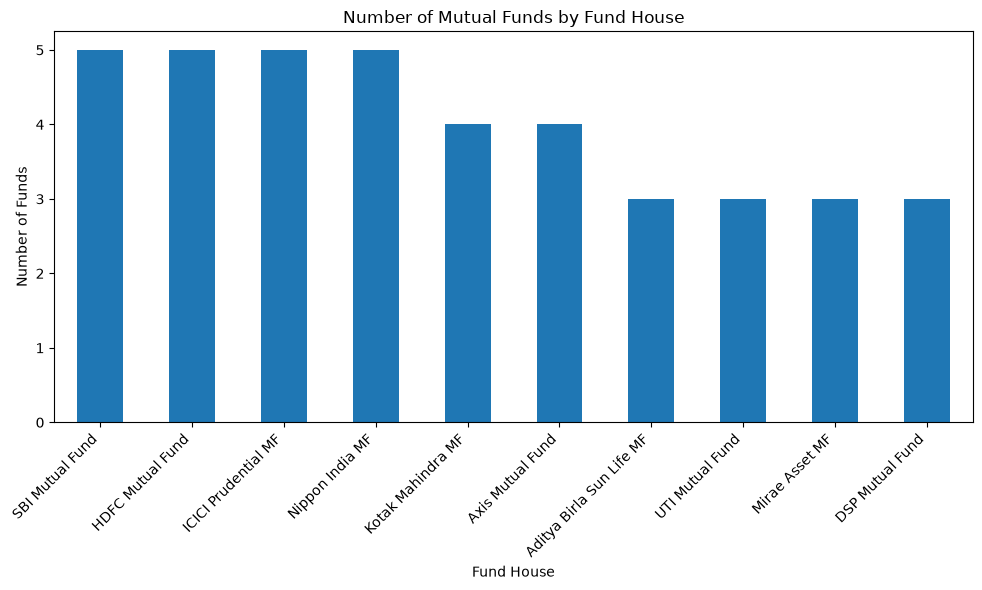

In [6]:
fund_house_counts = funds["fund_house"].value_counts()

plt.figure(figsize=(10, 6))

fund_house_counts.plot(kind="bar")

plt.title("Number of Mutual Funds by Fund House")
plt.xlabel("Fund House")
plt.ylabel("Number of Funds")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

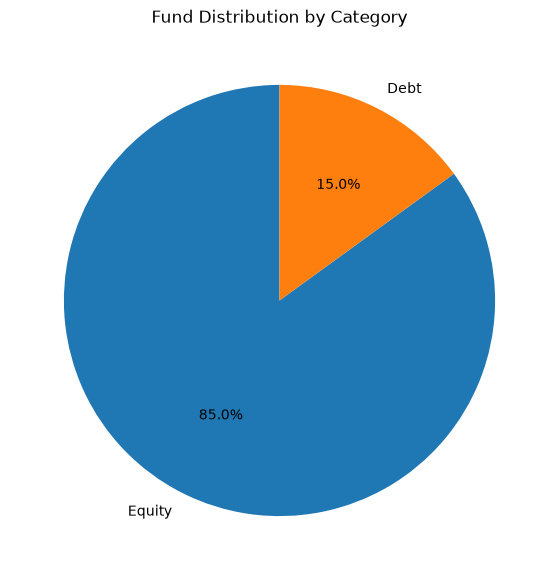

In [7]:
category_counts = funds["category"].value_counts()

plt.figure(figsize=(7, 7))

category_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Fund Distribution by Category")
plt.ylabel("")

plt.show()

In [8]:
nav = pd.read_csv("../data/processed/clean_nav.csv")

nav["date"] = pd.to_datetime(nav["date"])

print("NAV Data")
print("=" * 60)
print("Rows:", len(nav))
print("Columns:", len(nav.columns))

nav.head()

NAV Data
Rows: 46000
Columns: 3


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [9]:
print("NAV Fund Check")
print("=" * 60)

print("Unique funds:", nav["amfi_code"].nunique())
print("Total NAV records:", len(nav))
print("Missing NAV values:", nav["nav"].isna().sum())

NAV Fund Check
Unique funds: 40
Total NAV records: 46000
Missing NAV values: 0


In [10]:
print("NAV Date Range")
print("=" * 60)

print("Start date:", nav["date"].min().date())
print("End date:", nav["date"].max().date())

NAV Date Range
Start date: 2022-01-03
End date: 2026-05-29


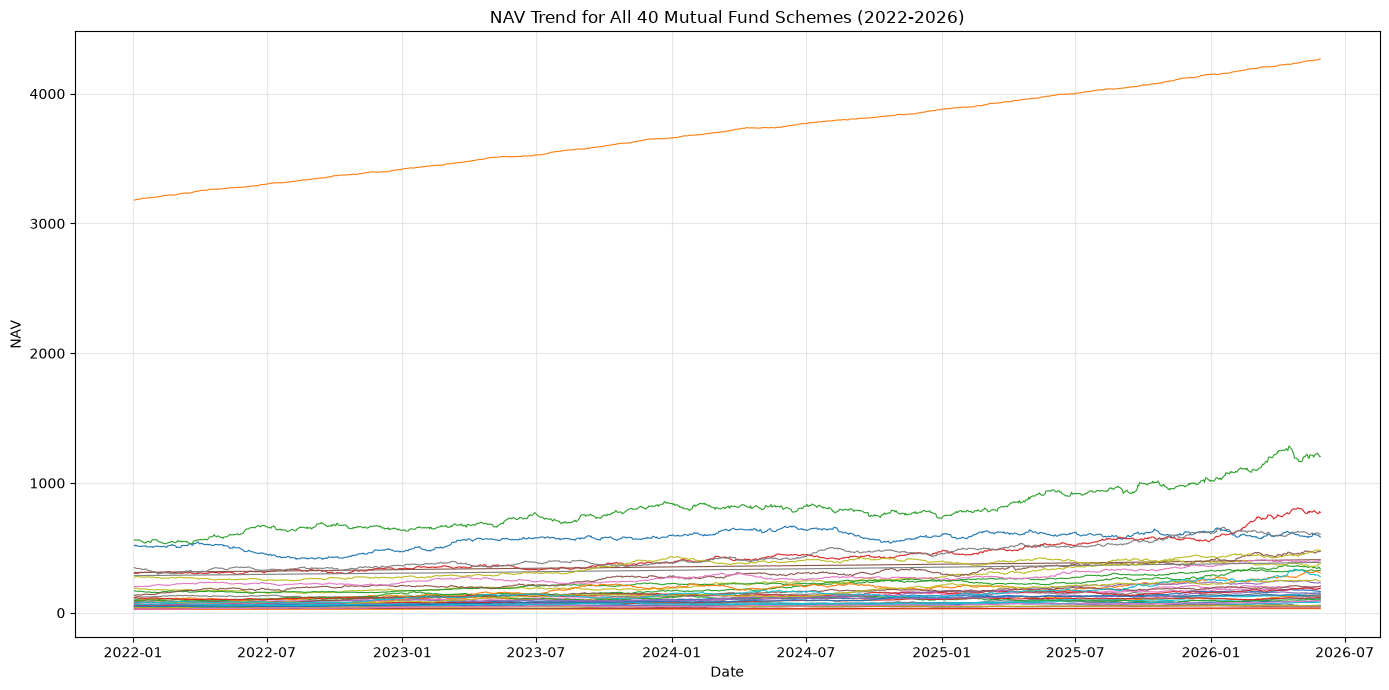

In [11]:
plt.figure(figsize=(14, 7))

for fund_code in nav["amfi_code"].unique():
    fund_data = nav[nav["amfi_code"] == fund_code]
    plt.plot(fund_data["date"], fund_data["nav"], linewidth=0.8)

plt.title("NAV Trend for All 40 Mutual Fund Schemes (2022-2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

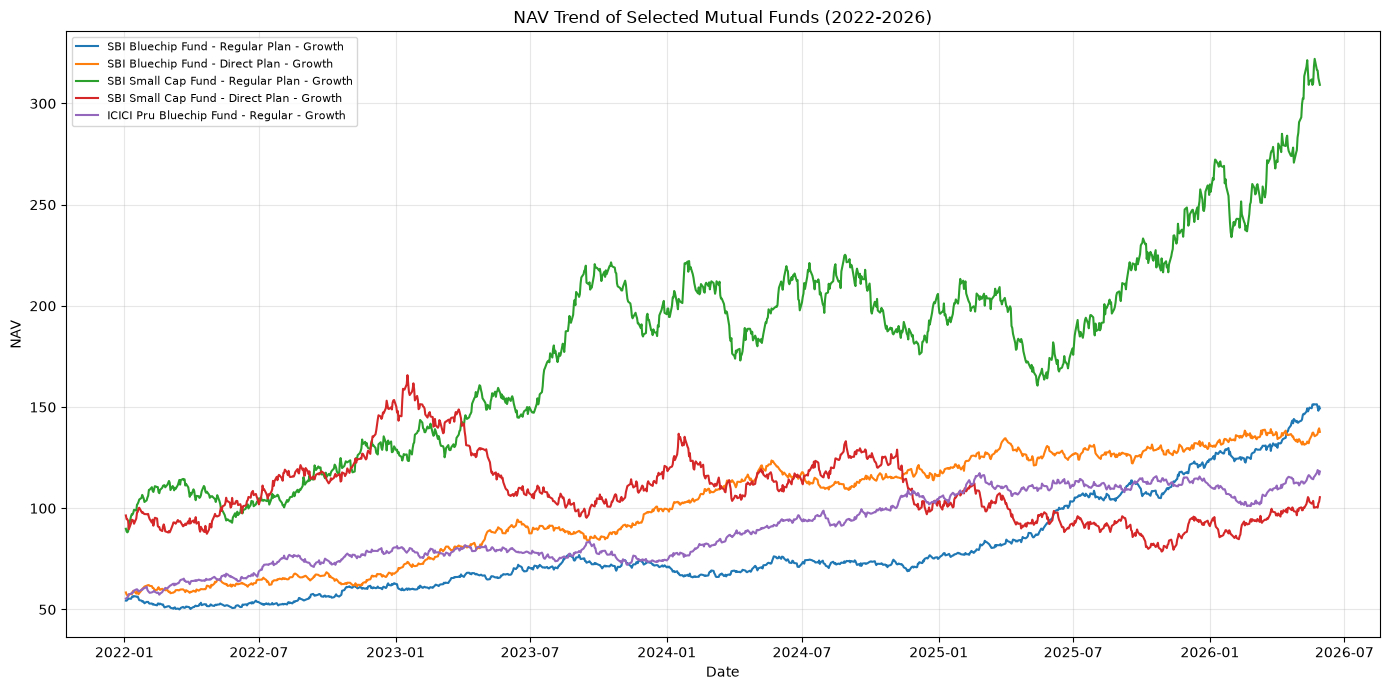

In [12]:
selected_codes = [119551, 119552, 119598, 119599, 120503]

selected_nav = nav[nav["amfi_code"].isin(selected_codes)]

plt.figure(figsize=(14, 7))

for code in selected_codes:
    fund_name = funds.loc[
        funds["amfi_code"] == code, "scheme_name"
    ].iloc[0]

    fund_data = selected_nav[selected_nav["amfi_code"] == code]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        label=fund_name
    )

plt.title("NAV Trend of Selected Mutual Funds (2022-2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
aum = pd.read_csv(
    "../data/raw/1788499984134-b0cbf625-03_aum_by_fund_house.csv"
)

aum["date"] = pd.to_datetime(aum["date"])

print("AUM Data")
print("=" * 60)
print("Rows:", len(aum))
print("Columns:", len(aum.columns))

aum.head()

AUM Data
Rows: 90
Columns: 5


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [15]:
print("AUM Years")
print("=" * 60)

print(aum["date"].dt.year.value_counts().sort_index())

AUM Years
date
2022    20
2023    20
2024    30
2025    20
Name: count, dtype: int64


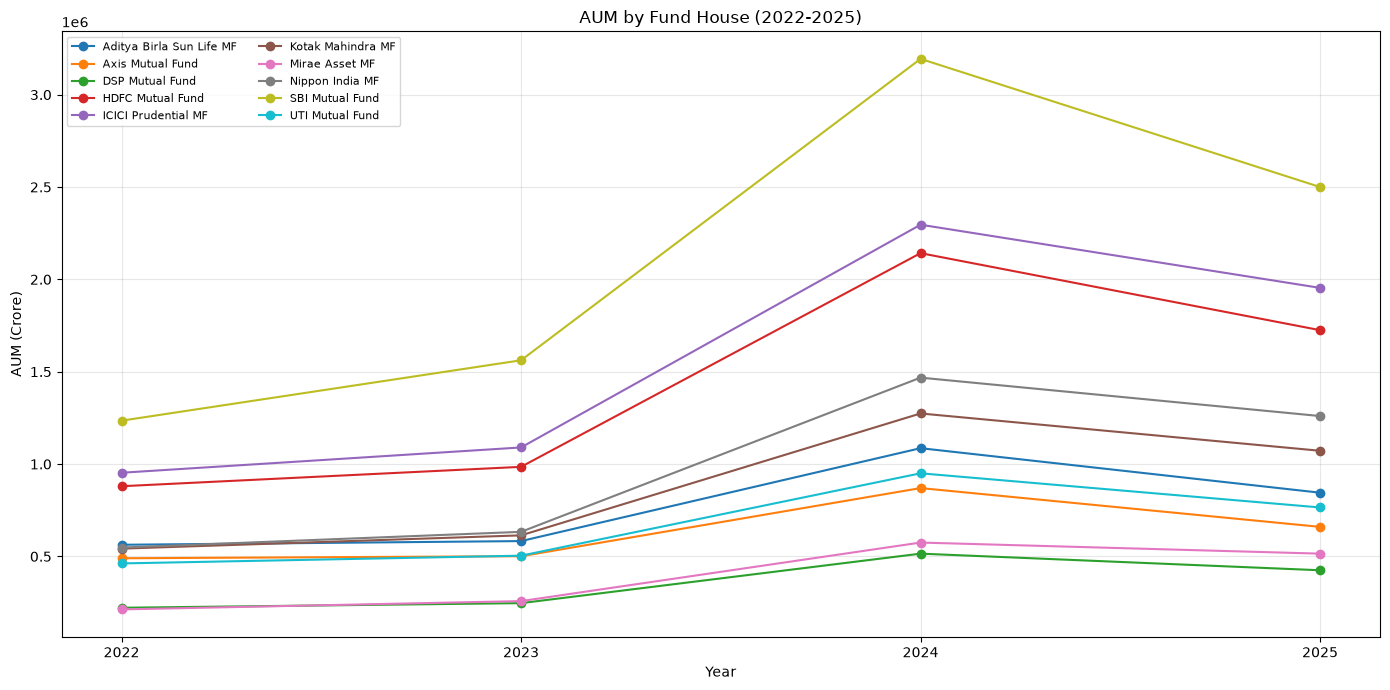

In [16]:
aum["year"] = aum["date"].dt.year

aum_yearly = (
    aum.groupby(["year", "fund_house"])["aum_crore"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 7))

for fund_house in aum_yearly["fund_house"].unique():
    data = aum_yearly[aum_yearly["fund_house"] == fund_house]
    plt.plot(
        data["year"],
        data["aum_crore"],
        marker="o",
        label=fund_house
    )

plt.title("AUM by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Crore)")
plt.xticks([2022, 2023, 2024, 2025])
plt.legend(fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
sip = pd.read_csv(
    "../data/raw/1788499984405-d702a6c6-04_monthly_sip_inflows.csv"
)

sip["month"] = pd.to_datetime(sip["month"])

print("Monthly SIP Data")
print("=" * 60)
print("Rows:", len(sip))
print("Columns:", len(sip.columns))

sip.head()

Monthly SIP Data
Rows: 48
Columns: 6


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [18]:
print("SIP Date Range")
print("=" * 60)

print("Start month:", sip["month"].min().strftime("%B %Y"))
print("End month:", sip["month"].max().strftime("%B %Y"))

SIP Date Range
Start month: January 2022
End month: December 2025


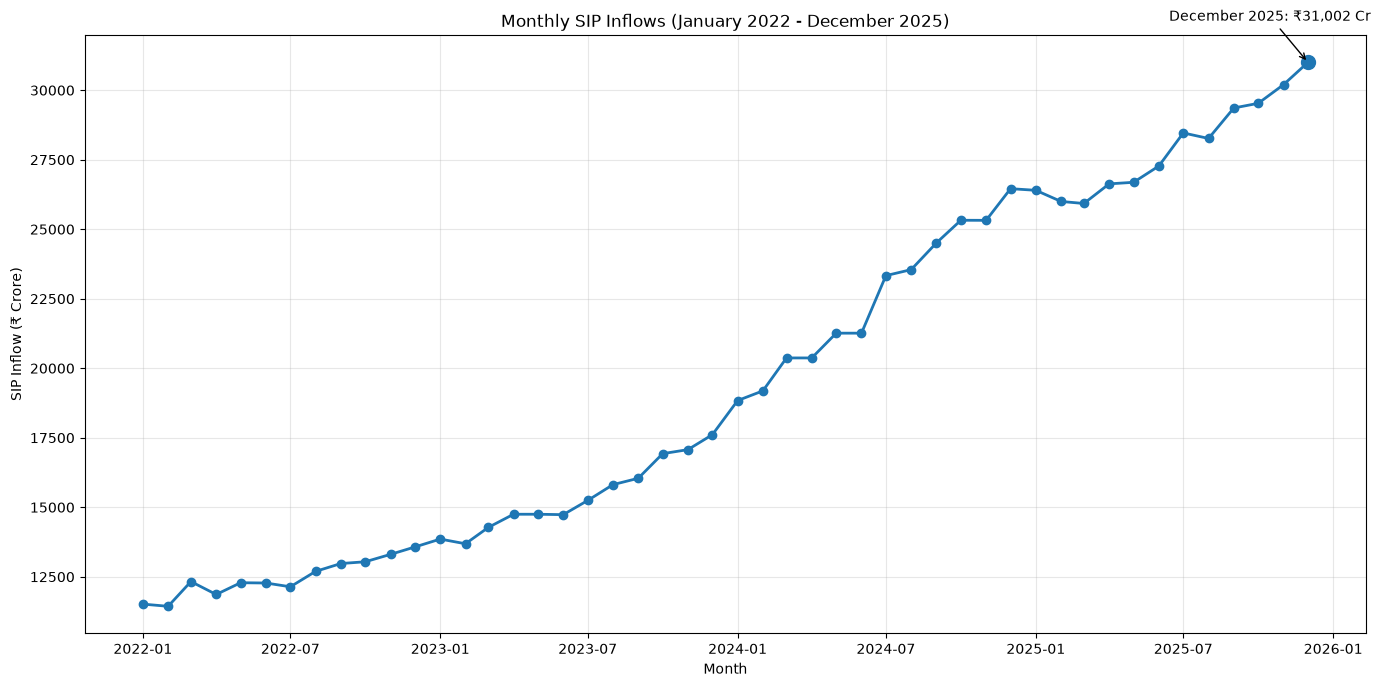

In [19]:
plt.figure(figsize=(14, 7))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o",
    linewidth=2
)

# Highlight December 2025
dec_2025 = sip[sip["month"] == "2025-12-01"]

plt.scatter(
    dec_2025["month"],
    dec_2025["sip_inflow_crore"],
    s=100
)

plt.annotate(
    "December 2025: ₹31,002 Cr",
    xy=(
        dec_2025["month"].iloc[0],
        dec_2025["sip_inflow_crore"].iloc[0]
    ),
    xytext=(-100, 30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Monthly SIP Inflows (January 2022 - December 2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

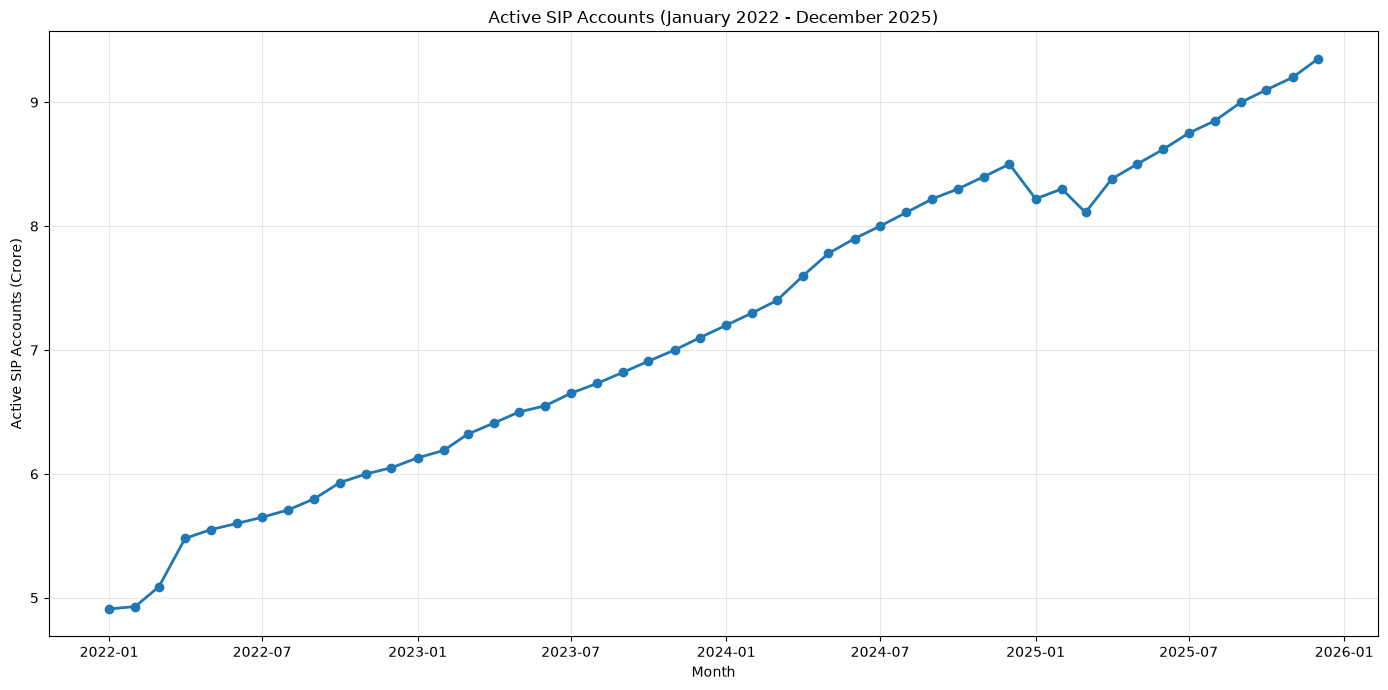

In [20]:
plt.figure(figsize=(14, 7))

plt.plot(
    sip["month"],
    sip["active_sip_accounts_crore"],
    marker="o",
    linewidth=2
)

plt.title("Active SIP Accounts (January 2022 - December 2025)")
plt.xlabel("Month")
plt.ylabel("Active SIP Accounts (Crore)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
category_inflows = pd.read_csv(
    "../data/raw/1788499984721-4b860901-05_category_inflows.csv"
)

category_inflows["month"] = pd.to_datetime(
    category_inflows["month"]
)

print("Category Inflow Data")
print("=" * 60)
print("Rows:", len(category_inflows))
print("Columns:", len(category_inflows.columns))

category_inflows.head()

Category Inflow Data
Rows: 144
Columns: 3


,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [22]:
print("Category Inflow Date Range")
print("=" * 60)

print("Start month:", category_inflows["month"].min().strftime("%B %Y"))
print("End month:", category_inflows["month"].max().strftime("%B %Y"))

print("\nCategories:")
print(category_inflows["category"].unique())

Category Inflow Date Range
Start month: April 2024
End month: March 2025

Categories:
<StringArray>
[        'Large Cap',           'Mid Cap',         'Small Cap',
         'Flexi Cap',   'Large & Mid Cap',              'ELSS',
      'Value/Contra', 'Sectoral/Thematic',            'Liquid',
    'Short Duration',              'Gilt',            'Hybrid']
Length: 12, dtype: str


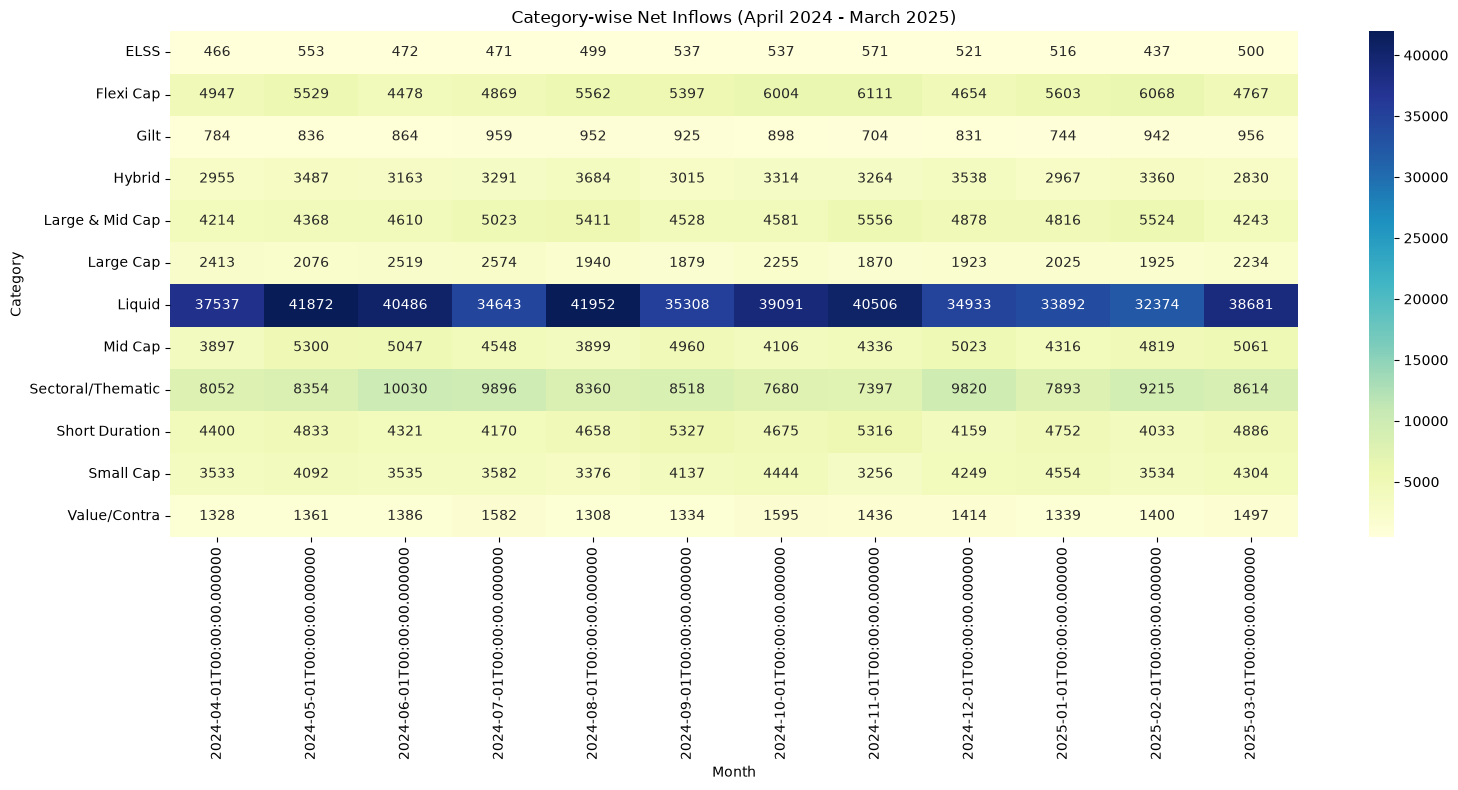

In [23]:
category_pivot = category_inflows.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(16, 8))

import seaborn as sns

sns.heatmap(
    category_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflows (April 2024 - March 2025)")
plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [26]:
transactions = pd.read_csv(
    "../data/raw/1788499980509-304c1255-08_investor_transactions.csv"
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

print("Investor Transaction Data")
print("=" * 60)
print("Rows:", len(transactions))
print("Columns:", len(transactions.columns))

transactions.head()
 

Investor Transaction Data
Rows: 32778
Columns: 13


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [27]:
print("Investor Age Groups")
print("=" * 60)

print(transactions["age_group"].value_counts(dropna=False))

Investor Age Groups
age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64


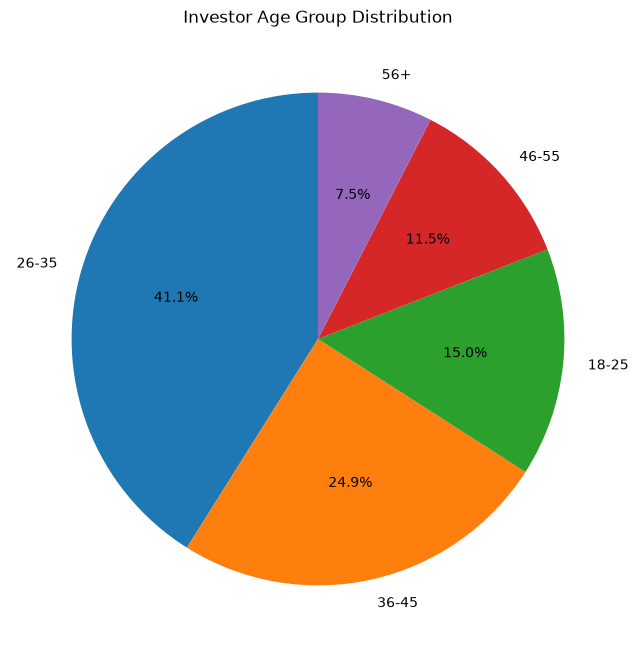

In [28]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8, 8))

age_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")

plt.show()

In [29]:
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

print("SIP Transactions")
print("=" * 60)
print("Number of SIP transactions:", len(sip_transactions))
print("Total SIP amount (₹):", sip_transactions["amount_inr"].sum())
print("\nSIP transactions by age group:")
print(sip_transactions["age_group"].value_counts())

SIP Transactions
Number of SIP transactions: 19716
Total SIP amount (₹): 217233491

SIP transactions by age group:
age_group
26-35    8063
36-45    4926
18-25    2949
46-55    2300
56+      1478
Name: count, dtype: int64


<Figure size 1000x700 with 0 Axes>

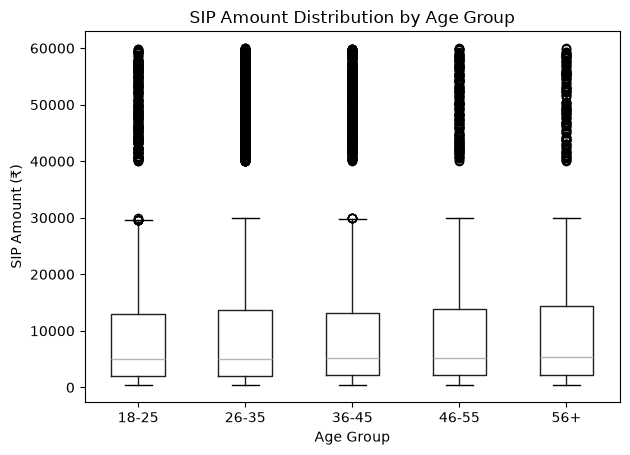

In [30]:
plt.figure(figsize=(10, 7))

sip_transactions.boxplot(
    column="amount_inr",
    by="age_group",
    grid=False
)

plt.title("SIP Amount Distribution by Age Group")
plt.suptitle("")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.tight_layout()
plt.show()

In [31]:
print("T30 vs B30")
print("=" * 60)

print(transactions["city_tier"].value_counts())

T30 vs B30
city_tier
T30    21719
B30    11059
Name: count, dtype: int64


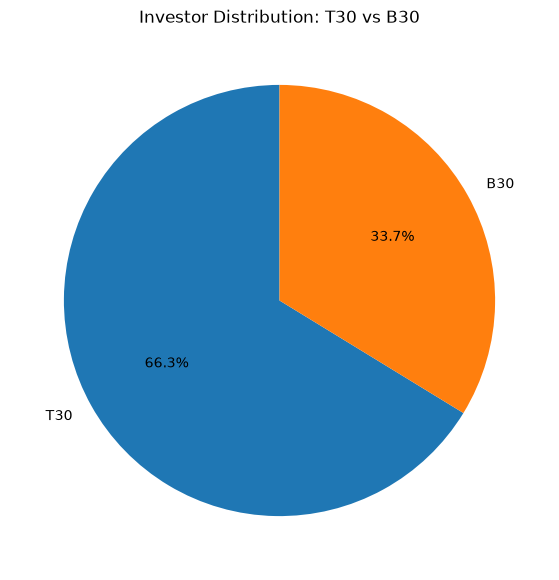

In [32]:
tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(7, 7))

tier_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution: T30 vs B30")
plt.ylabel("")

plt.show()

In [33]:
state_sip = (
    sip_transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print("SIP Amount by State")
print("=" * 60)

print(state_sip)

SIP Amount by State
state
Madhya Pradesh    20682243
Punjab            20140064
Telangana         18620216
Tamil Nadu        18404368
Gujarat           18378904
Haryana           18176696
Karnataka         17696903
Uttar Pradesh     17534858
West Bengal       17495769
Delhi             17113608
Rajasthan         16544233
Maharashtra       16445629
Name: amount_inr, dtype: int64


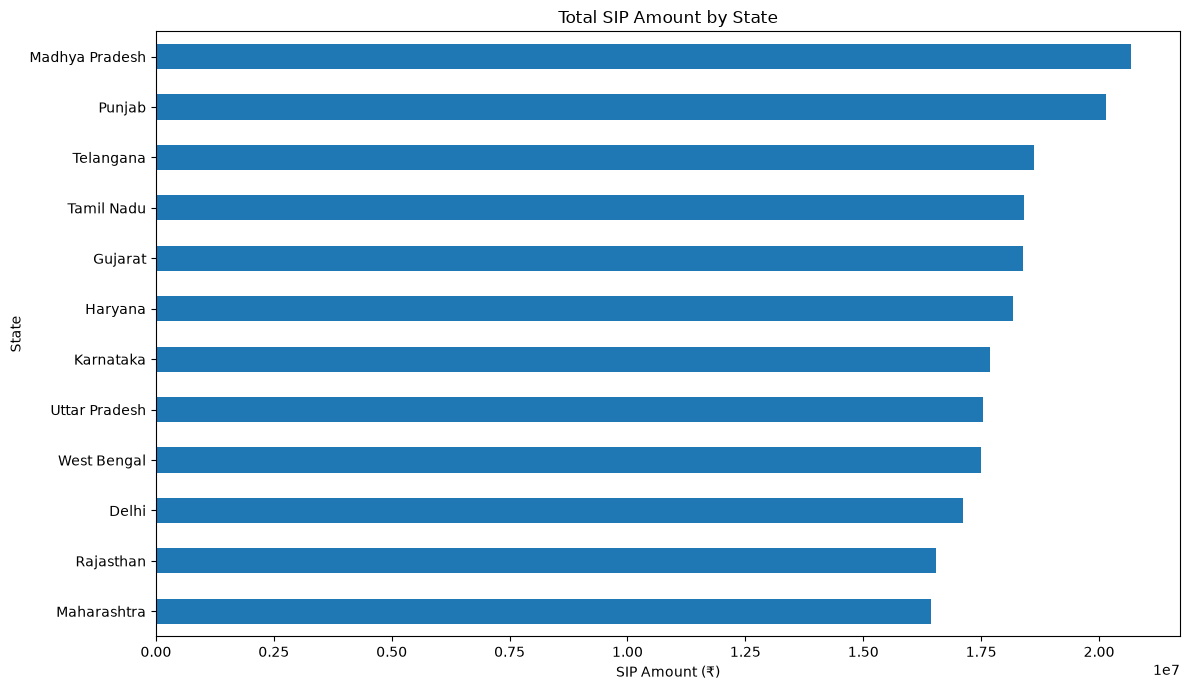

In [34]:
plt.figure(figsize=(12, 7))

state_sip.sort_values().plot(
    kind="barh"
)

plt.title("Total SIP Amount by State")
plt.xlabel("SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [35]:
folios = pd.read_csv(
    "../data/raw/1788499985036-da4a0c4a-06_industry_folio_count.csv"
)

folios["month"] = pd.to_datetime(folios["month"])

print("Folio Data")
print("=" * 60)
print("Rows:", len(folios))
print("Columns:", len(folios.columns))

folios.head()

Folio Data
Rows: 21
Columns: 6


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [36]:
print("Folio Date Range")
print("=" * 60)

print("Start month:", folios["month"].min().strftime("%B %Y"))
print("End month:", folios["month"].max().strftime("%B %Y"))

Folio Date Range
Start month: January 2022
End month: December 2025


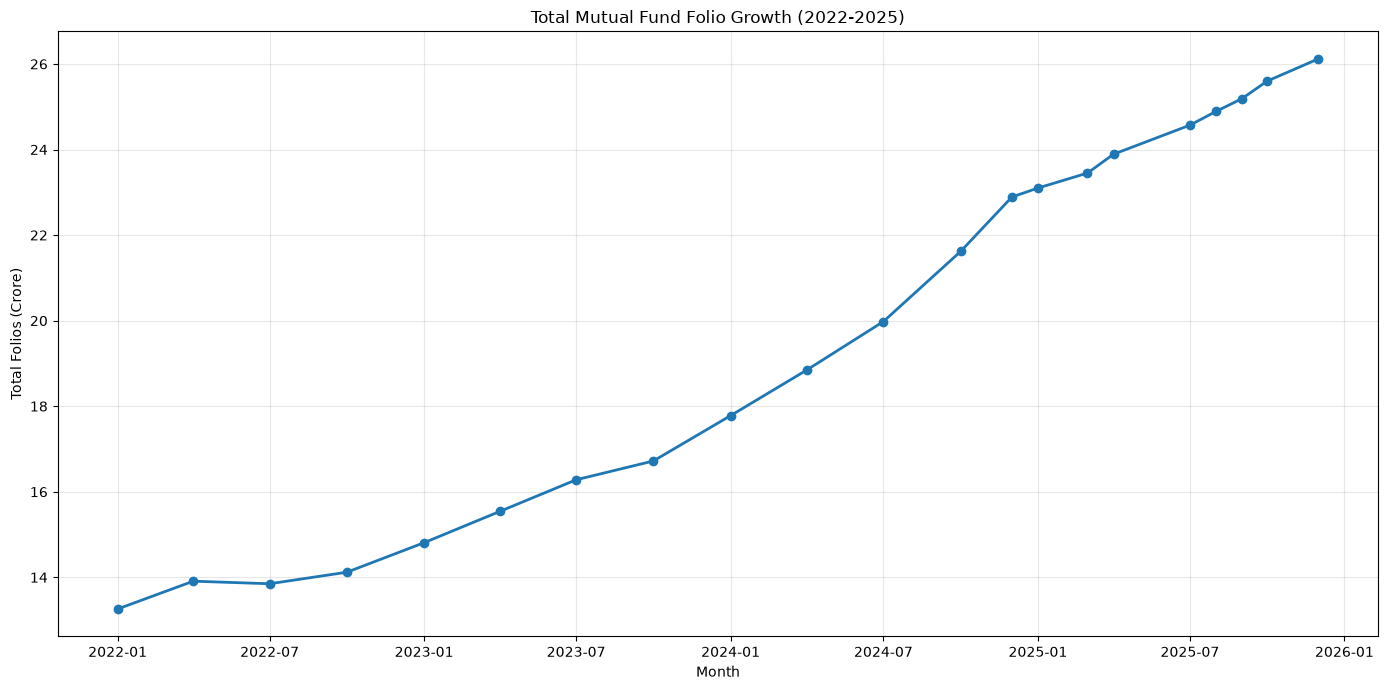

In [37]:
plt.figure(figsize=(14, 7))

plt.plot(
    folios["month"],
    folios["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Total Mutual Fund Folio Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
print("Latest Folio Counts")
print("=" * 60)

print(
    folios.iloc[-1][
        [
            "month",
            "total_folios_crore",
            "equity_folios_crore",
            "debt_folios_crore",
            "hybrid_folios_crore",
            "others_folios_crore"
        ]
    ]
)

Latest Folio Counts
month                  2025-12-01 00:00:00
total_folios_crore                   26.12
equity_folios_crore                  18.28
debt_folios_crore                     3.66
hybrid_folios_crore                   1.57
others_folios_crore                   2.61
Name: 20, dtype: object


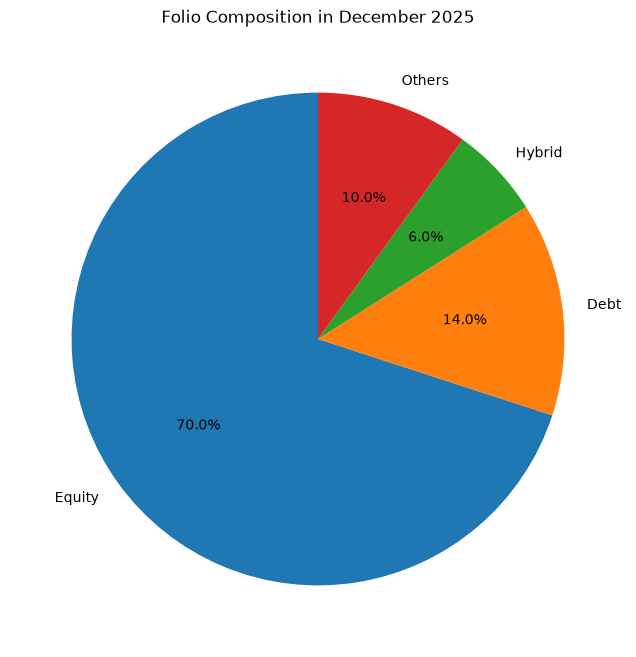

In [39]:
latest_folios = folios.iloc[-1]

folio_categories = pd.Series({
    "Equity": latest_folios["equity_folios_crore"],
    "Debt": latest_folios["debt_folios_crore"],
    "Hybrid": latest_folios["hybrid_folios_crore"],
    "Others": latest_folios["others_folios_crore"]
})

plt.figure(figsize=(8, 8))

folio_categories.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Folio Composition in December 2025")
plt.ylabel("")

plt.show()

In [40]:
nav_returns = nav.copy()

nav_returns["daily_return"] = (
    nav_returns
    .groupby("amfi_code")["nav"]
    .pct_change()
)

print("Daily Return Check")
print("=" * 60)

print("Total records:", len(nav_returns))
print("Missing daily returns:", nav_returns["daily_return"].isna().sum())

Daily Return Check
Total records: 46000
Missing daily returns: 40


In [41]:
selected_10 = nav_returns["amfi_code"].unique()[:10]

correlation_data = (
    nav_returns[
        nav_returns["amfi_code"].isin(selected_10)
    ]
    .pivot(
        index="date",
        columns="amfi_code",
        values="daily_return"
    )
)

print("Correlation Data")
print("=" * 60)
print("Funds selected:", len(selected_10))
print("Rows:", len(correlation_data))
print("Columns:", len(correlation_data.columns))

correlation_data.head()

Correlation Data
Funds selected: 10
Rows: 1150
Columns: 10


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


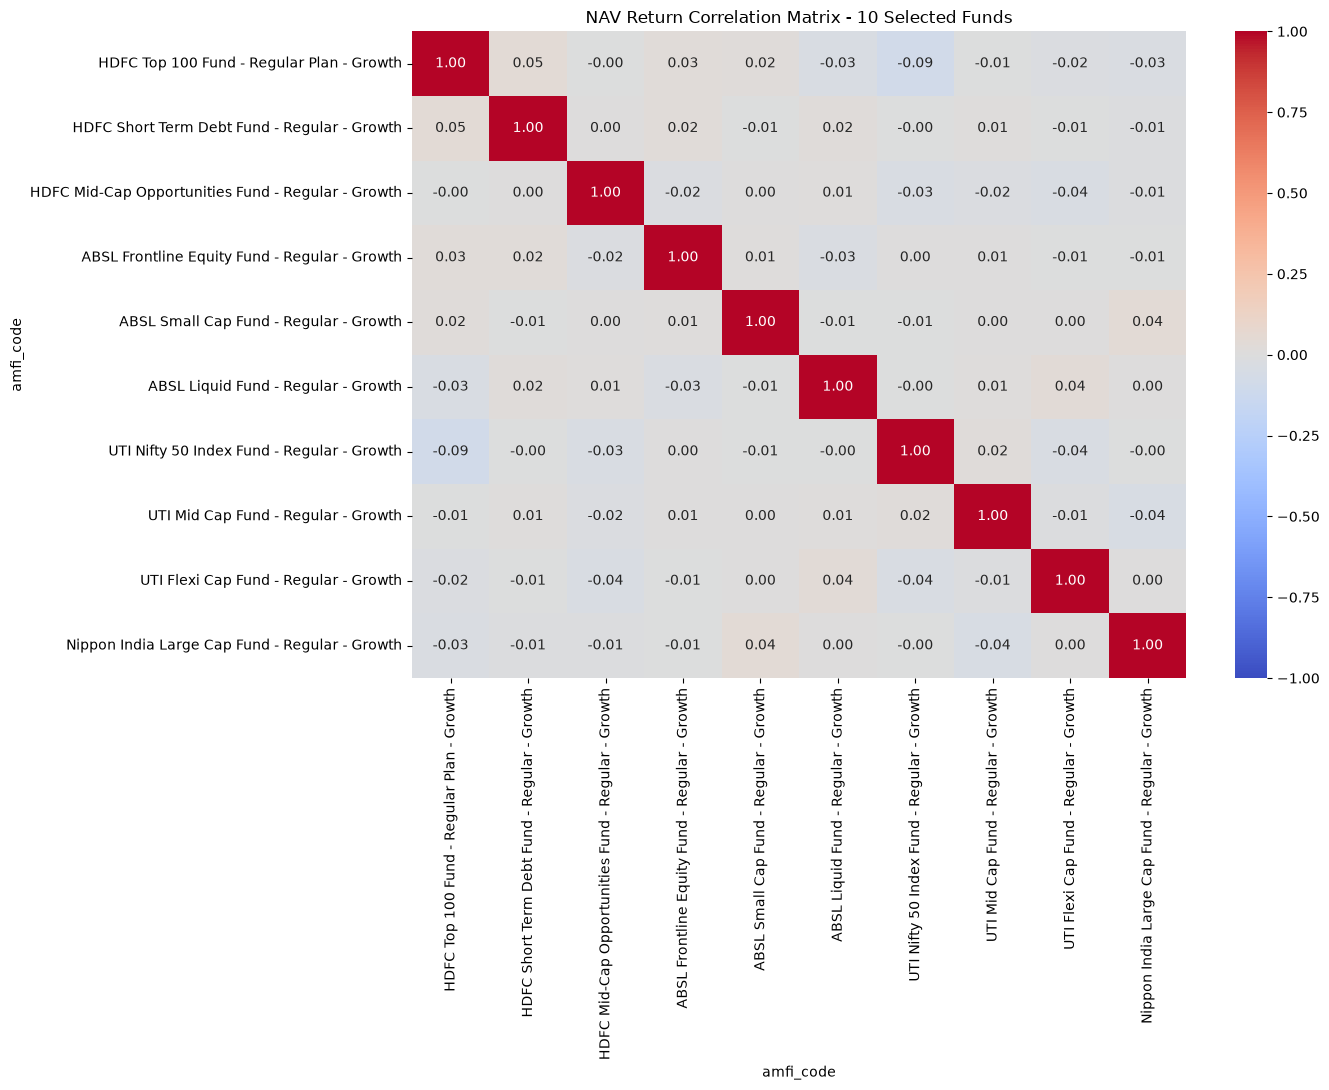

In [42]:
correlation_matrix = correlation_data.corr()

# Replace AMFI codes with fund names
fund_names = {}

for code in correlation_matrix.columns:
    name = funds.loc[
        funds["amfi_code"] == code, "scheme_name"
    ].iloc[0]
    fund_names[code] = name

correlation_matrix = correlation_matrix.rename(
    index=fund_names,
    columns=fund_names
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("NAV Return Correlation Matrix - 10 Selected Funds")
plt.tight_layout()

plt.show()

In [43]:
print("Transaction Types")
print("=" * 60)

print(transactions["transaction_type"].value_counts())

Transaction Types
transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64


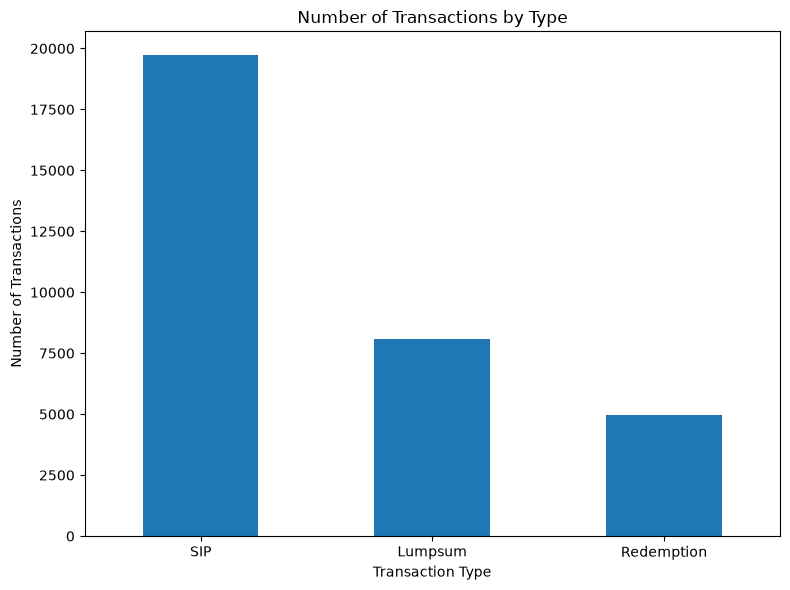

In [44]:
transaction_counts = transactions["transaction_type"].value_counts()

plt.figure(figsize=(8, 6))

transaction_counts.plot(
    kind="bar"
)

plt.title("Number of Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [45]:
print("Payment Modes")
print("=" * 60)

print(transactions["payment_mode"].value_counts())

Payment Modes
payment_mode
Net Banking    8250
Cheque         8228
UPI            8154
Mandate        8146
Name: count, dtype: int64


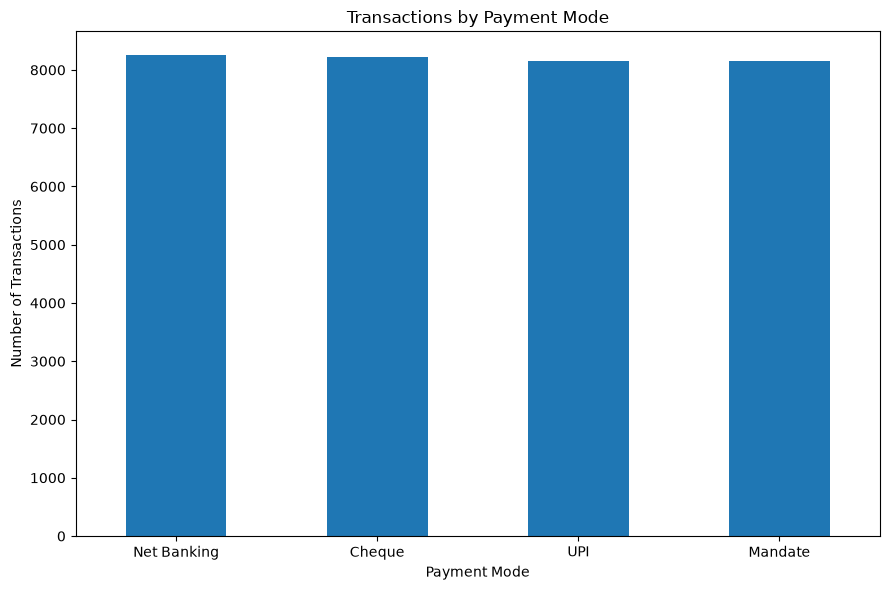

In [46]:
payment_counts = transactions["payment_mode"].value_counts()

plt.figure(figsize=(9, 6))

payment_counts.plot(
    kind="bar"
)

plt.title("Transactions by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [47]:
print("Fund Risk Categories")
print("=" * 60)

print(funds["risk_category"].value_counts())

Fund Risk Categories
risk_category
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64


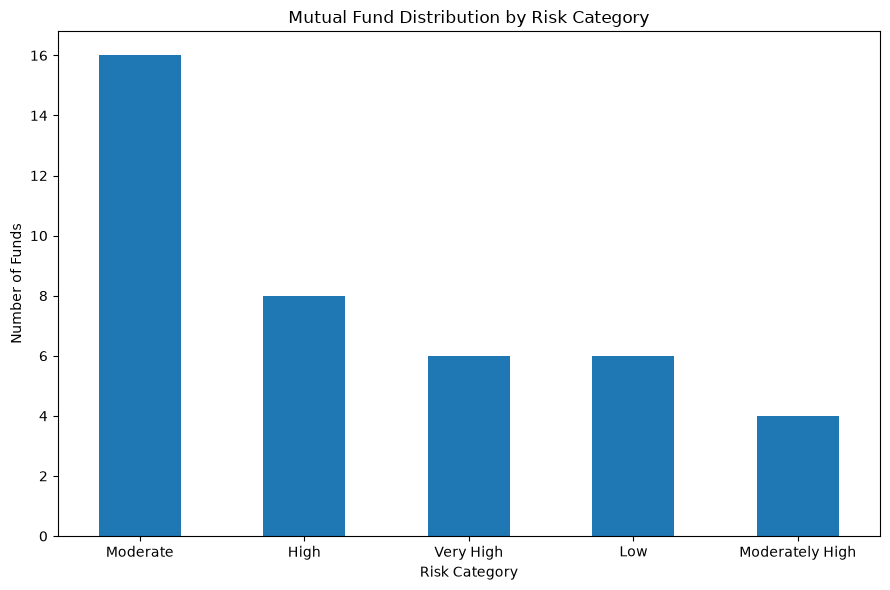

In [48]:
risk_counts = funds["risk_category"].value_counts()

plt.figure(figsize=(9, 6))

risk_counts.plot(
    kind="bar"
)

plt.title("Mutual Fund Distribution by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Number of Funds")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## EDA Findings

### 1. Fund Category Distribution
The dataset contains 40 mutual fund schemes. Equity funds represent 85% of the schemes, while Debt funds represent 15%.

### 2. Fund House Distribution
SBI Mutual Fund, HDFC Mutual Fund, ICICI Prudential MF, and Nippon India MF each have 5 schemes in the dataset.

### 3. NAV Trend
NAV values for all 40 schemes were analyzed from January 2022 to May 2026. The selected-fund analysis shows different NAV growth patterns across schemes.

### 4. AUM Trend
SBI Mutual Fund has the highest AUM among the fund houses in the available 2022-2025 AUM data. AUM values reach their highest observed levels in 2024 for several major fund houses.

### 5. SIP Inflows
Monthly SIP inflows increased substantially from ₹11,517 crore in January 2022 to ₹31,002 crore in December 2025.

### 6. Active SIP Accounts
Active SIP accounts increased from approximately 4.91 crore in January 2022 to approximately 9.35 crore in December 2025.

### 7. Category Inflows
Liquid funds recorded the highest net inflows throughout the available April 2024 to March 2025 category-inflow period.

### 8. Investor Age Distribution
The 26-35 age group represents the largest share of transactions at 41.1%, followed by the 36-45 age group at 24.9%.

### 9. Geographic Distribution
T30 cities account for 66.3% of transactions, while B30 cities account for 33.7%.

### 10. Folio Growth
Total mutual fund folios increased from 13.26 crore in January 2022 to 26.12 crore in December 2025.

### 11. Folio Composition
In December 2025, equity folios represented approximately 70% of total folios, followed by debt at 14%, others at 10%, and hybrid at 6%.

### 12. Transaction Behavior
SIP is the most common transaction type, with 19,716 transactions, followed by Lumpsum with 8,095 and Redemption with 4,967.

### 13. Payment Modes
Net Banking, Cheque, UPI, and Mandate transactions are relatively evenly distributed in the dataset.

### 14. Risk Distribution
Moderate-risk funds form the largest risk category, with 16 of the 40 schemes.

### 15. NAV Return Correlation
The selected 10 funds show mostly weak linear correlations in their daily NAV returns, with most correlation values close to zero.

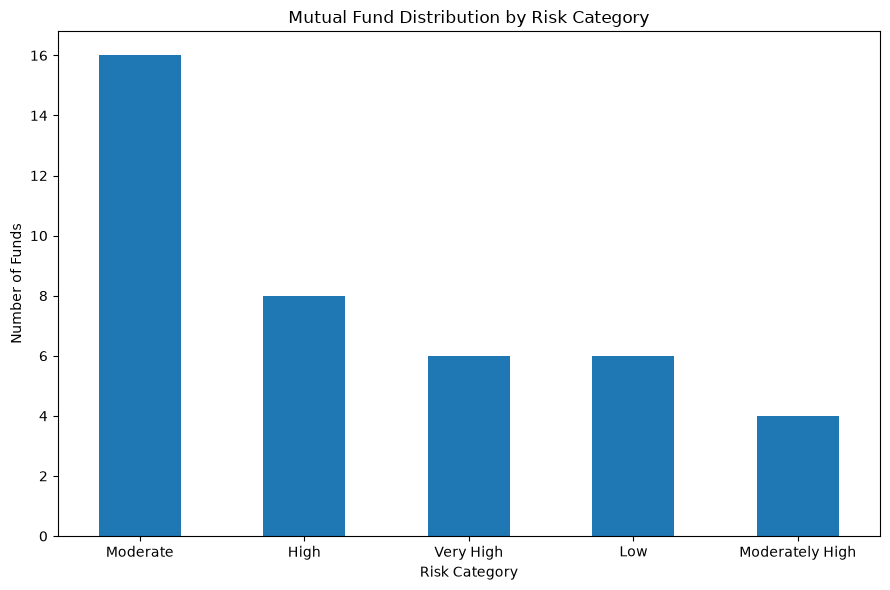

Chart 18 saved successfully!


In [49]:
risk_counts = funds["risk_category"].value_counts()

plt.figure(figsize=(9, 6))

risk_counts.plot(kind="bar")

plt.title("Mutual Fund Distribution by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Number of Funds")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../reports/eda_charts/18_risk_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart 18 saved successfully!")

In [51]:
import os

chart_folder = "../reports/eda_charts"

os.makedirs(chart_folder, exist_ok=True)

print("EDA chart folder is ready!")
print("Location:", chart_folder)

EDA chart folder is ready!
Location: ../reports/eda_charts


In [ ]:
import os
import seaborn as sns
import matplotlib.pyplot as plt

chart_folder = "../reports/eda_charts"
os.makedirs(chart_folder, exist_ok=True)

# 1. Fund House Distribution
fund_house_counts = funds["fund_house"].value_counts()

plt.figure(figsize=(12, 6))
fund_house_counts.plot(kind="bar")
plt.title("Number of Mutual Funds by Fund House")
plt.xlabel("Fund House")
plt.ylabel("Number of Funds")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{chart_folder}/01_fund_house_distribution.png", dpi=300, bbox_inches="tight")
plt.close()


# 2. Fund Category Distribution
category_counts = funds["category"].value_counts()

plt.figure(figsize=(8, 8))
category_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Fund Distribution by Category")
plt.ylabel("")
plt.tight_layout()
plt.savefig(f"{chart_folder}/02_fund_category_distribution.png", dpi=300, bbox_inches="tight")
plt.close()


# 3. NAV Trend - All 40 Funds
plt.figure(figsize=(14, 7))

for code in nav["amfi_code"].unique():
    fund_data = nav[nav["amfi_code"] == code]
    plt.plot(fund_data["date"], fund_data["nav"], linewidth=0.7)

plt.title("NAV Trend for All 40 Mutual Fund Schemes (2022-2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{chart_folder}/03_nav_all_40_funds.png", dpi=300, bbox_inches="tight")
plt.close()


# 4. NAV Trend - Selected 5 Funds
selected_codes = [119551, 119552, 119598, 119599, 120503]
selected_nav = nav[nav["amfi_code"].isin(selected_codes)]

plt.figure(figsize=(14, 7))

for code in selected_codes:
    fund_name = funds.loc[
        funds["amfi_code"] == code, "scheme_name"
    ].iloc[0]

    fund_data = selected_nav[selected_nav["amfi_code"] == code]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        label=fund_name
    )

plt.title("NAV Trend of Selected Mutual Funds (2022-2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{chart_folder}/04_nav_selected_funds.png", dpi=300, bbox_inches="tight")
plt.close()


# 5. AUM by Fund House
aum["year"] = aum["date"].dt.year

aum_yearly = (
    aum.groupby(["year", "fund_house"])["aum_crore"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 7))

for fund_house in aum_yearly["fund_house"].unique():
    data = aum_yearly[aum_yearly["fund_house"] == fund_house]
    plt.plot(
        data["year"],
        data["aum_crore"],
        marker="o",
        label=fund_house
    )

plt.title("AUM by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Crore)")
plt.xticks([2022, 2023, 2024, 2025])
plt.legend(fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{chart_folder}/05_aum_by_fund_house.png", dpi=300, bbox_inches="tight")
plt.close()


# 6. Monthly SIP Inflows
plt.figure(figsize=(14, 7))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o",
    linewidth=2
)

dec_2025 = sip[sip["month"] == "2025-12-01"]

plt.scatter(
    dec_2025["month"],
    dec_2025["sip_inflow_crore"],
    s=100
)

plt.annotate(
    "December 2025: ₹31,002 Cr",
    xy=(
        dec_2025["month"].iloc[0],
        dec_2025["sip_inflow_crore"].iloc[0]
    ),
    xytext=(-100, 30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Monthly SIP Inflows (January 2022 - December 2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{chart_folder}/06_monthly_sip_inflows.png", dpi=300, bbox_inches="tight")
plt.close()


# 7. Active SIP Accounts
plt.figure(figsize=(14, 7))

plt.plot(
    sip["month"],
    sip["active_sip_accounts_crore"],
    marker="o",
    linewidth=2
)

plt.title("Active SIP Accounts (January 2022 - December 2025)")
plt.xlabel("Month")
plt.ylabel("Active SIP Accounts (Crore)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{chart_folder}/07_active_sip_accounts.png", dpi=300, bbox_inches="tight")
plt.close()


# 8. Category-wise Net Inflows
category_pivot = category_inflows.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(16, 8))

sns.heatmap(
    category_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflows (April 2024 - March 2025)")
plt.xlabel("Month")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(f"{chart_folder}/08_category_inflow_heatmap.png", dpi=300, bbox_inches="tight")
plt.close()


# 9. Investor Age Distribution
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8, 8))
age_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")
plt.tight_layout()
plt.savefig(f"{chart_folder}/09_investor_age_distribution.png", dpi=300, bbox_inches="tight")
plt.close()


# 10. SIP Amount by Age Group
plt.figure(figsize=(10, 7))

sip_transactions.boxplot(
    column="amount_inr",
    by="age_group",
    grid=False
)

plt.title("SIP Amount Distribution by Age Group")
plt.suptitle("")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")
plt.tight_layout()
plt.savefig(f"{chart_folder}/10_sip_amount_by_age.png", dpi=300, bbox_inches="tight")
plt.close()


# 11. T30 vs B30
tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(7, 7))

tier_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution: T30 vs B30")
plt.ylabel("")
plt.tight_layout()
plt.savefig(f"{chart_folder}/11_t30_vs_b30.png", dpi=300, bbox_inches="tight")
plt.close()


# 12. SIP Amount by State
state_sip = (
    sip_transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

state_sip.sort_values().plot(
    kind="barh"
)

plt.title("Total SIP Amount by State")
plt.xlabel("SIP Amount (₹)")
plt.ylabel("State")
plt.tight_layout()
plt.savefig(f"{chart_folder}/12_sip_amount_by_state.png", dpi=300, bbox_inches="tight")
plt.close()


# 13. Folio Growth
plt.figure(figsize=(14, 7))

plt.plot(
    folios["month"],
    folios["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Total Mutual Fund Folio Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{chart_folder}/13_folio_growth.png", dpi=300, bbox_inches="tight")
plt.close()


# 14. Folio Composition
latest_folios = folios.iloc[-1]

folio_categories = pd.Series({
    "Equity": latest_folios["equity_folios_crore"],
    "Debt": latest_folios["debt_folios_crore"],
    "Hybrid": latest_folios["hybrid_folios_crore"],
    "Others": latest_folios["others_folios_crore"]
})

plt.figure(figsize=(8, 8))

folio_categories.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Folio Composition in December 2025")
plt.ylabel("")
plt.tight_layout()
plt.savefig(f"{chart_folder}/14_folio_composition.png", dpi=300, bbox_inches="tight")
plt.close()


# 15. NAV Return Correlation
correlation_matrix = correlation_data.corr()

fund_names = {}

for code in correlation_matrix.columns:
    name = funds.loc[
        funds["amfi_code"] == code, "scheme_name"
    ].iloc[0]
    fund_names[code] = name

correlation_matrix = correlation_matrix.rename(
    index=fund_names,
    columns=fund_names
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("NAV Return Correlation Matrix - 10 Selected Funds")
plt.tight_layout()
plt.savefig(f"{chart_folder}/15_nav_return_correlation.png", dpi=300, bbox_inches="tight")
plt.close()


# 16. Transaction Types
transaction_counts = transactions["transaction_type"].value_counts()

plt.figure(figsize=(8, 6))

transaction_counts.plot(
    kind="bar"
)

plt.title("Number of Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{chart_folder}/16_transaction_types.png", dpi=300, bbox_inches="tight")
plt.close()


# 17. Payment Modes
payment_counts = transactions["payment_mode"].value_counts()

plt.figure(figsize=(9, 6))

payment_counts.plot(
    kind="bar"
)

plt.title("Transactions by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{chart_folder}/17_payment_modes.png", dpi=300, bbox_inches="tight")
plt.close()


# 18. Risk Categories
risk_counts = funds["risk_category"].value_counts()

plt.figure(figsize=(9, 6))

risk_counts.plot(
    kind="bar"
)

plt.title("Mutual Fund Distribution by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Number of Funds")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{chart_folder}/18_risk_category_distribution.png", dpi=300, bbox_inches="tight")
plt.close()


print("All 18 EDA charts saved successfully!")
print("Folder:", chart_folder)
print("Number of charts:", len(os.listdir(chart_folder)))

All 18 EDA charts saved successfully!
Folder: ../reports/eda_charts
Number of charts: 18


<Figure size 1000x700 with 0 Axes>

# EDA Findings

## 10 Key Findings

1. **Fund category distribution:** Equity funds make up 85% of the 40 funds, while Debt funds make up 15%. The dataset therefore has a strong focus on equity-oriented mutual funds.

2. **Fund house distribution:** SBI Mutual Fund, HDFC Mutual Fund, ICICI Prudential MF, and Nippon India MF have the highest representation with 5 funds each.

3. **NAV trend:** The NAV data covers 40 mutual fund schemes from January 2022 to May 2026, with 46,000 records and no missing NAV values.

4. **AUM trend:** SBI Mutual Fund has the highest AUM among the fund houses in the available AUM dataset. AUM increased strongly through 2024 before declining in 2025 for the major fund houses.

5. **SIP growth:** Monthly SIP inflows increased from ₹11,517 crore in January 2022 to ₹31,002 crore in December 2025, showing strong growth in SIP investment activity.

6. **Active SIP accounts:** Active SIP accounts increased from 4.91 crore in January 2022 to about 9.35 crore in December 2025, showing a strong increase in the number of active SIP investors.

7. **Investor age:** The 26-35 age group is the largest investor group, representing 41.1% of the transaction records. The 36-45 age group is the second-largest at 24.9%.

8. **Geographic distribution:** T30 cities account for 66.3% of the investor transaction records, while B30 cities account for 33.7%. Madhya Pradesh has the highest total SIP amount among the states in the dataset.

9. **Folio growth:** Total mutual fund folios increased from 13.26 crore in January 2022 to 26.12 crore in December 2025. Equity folios form the largest part of the December 2025 folio base.

10. **Investor transactions and risk:** SIP is the most common transaction type with 19,716 transactions. Moderate-risk funds are the largest risk category with 16 out of 40 funds. Payment modes are relatively evenly distributed across Net Banking, Cheque, UPI, and Mandate.